<a href="https://colab.research.google.com/github/sampabiet90/AIML/blob/LogicMojo-AI-ML-April26-sampa90/Leads_Score_Assignment_Logistic_REgression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Leads Scoring Assignment Using Logistic Regression**

An education company named X Education sells online courses to industry professionals.
 The company requires you to build a model wherein you need to assign a lead score to each of the leads such that the customers with higher lead score have a higher conversion chance and the customers with lower lead score have a lower conversion chance. The CEO, in particular, has given a ballpark of the target lead conversion rate to be around 80%.

 Build a logistic regression model to assign a lead score between 0 and 100 to each of the leads which can be used by the company to target potential leads. A higher score would mean that the lead is hot, i.e. is most likely to convert whereas a lower score would mean that the lead is cold and will mostly not get converted.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [106]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/LeadScoringAssignment-logisticRegression/Leads.csv')

In [5]:
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [7]:
df.describe()

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


In [8]:
df.shape

(9240, 37)

Now we will findout which columns are relevant to target varibale "coverted"

In [107]:
pd.crosstab(df['Lead Origin'],df['Converted'],normalize='index')*100

Converted,0,1
Lead Origin,,
API,68.854749,31.145251
Landing Page Submission,63.814982,36.185018
Lead Add Form,7.520891,92.479109
Lead Import,76.363636,23.636364
Quick Add Form,0.000000,100.000000


In [108]:
#Lead Origin is useful so we will use one hot encoding to convert it to number
df = pd.get_dummies(df, columns=['Lead Origin'], drop_first=True)

In [109]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

,0
Lead Quality,51.590909
Asymmetrique Profile Index,45.649351
Asymmetrique Activity Index,45.649351
Asymmetrique Activity Score,45.649351
Asymmetrique Profile Score,45.649351
Tags,36.287879
What matters most to you in choosing a course,29.318182
Lead Profile,29.318182
What is your current occupation,29.112554
Country,26.634199


In [110]:
pd.crosstab(df['Lead Quality'],df['Converted'],normalize='index')*100

Converted,0,1
Lead Quality,,
High in Relevance,5.337520,94.662480
Low in Relevance,18.181818,81.818182
Might be,24.423077,75.576923
Not Sure,75.641026,24.358974
Worst,98.003328,1.996672


In [111]:
#Lead Origin is useful so we will use one hot encoding to convert it to number
df = pd.get_dummies(df, columns=['Lead Quality'], drop_first=True)

In [112]:
df.columns

Index(['Prospect ID', 'Lead Number', 'Lead Source', 'Do Not Email',
       'Do Not Call', 'Converted', 'TotalVisits',
       'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity',
       'Country', 'Specialization', 'How did you hear about X Education',
       'What is your current occupation',
       'What matters most to you in choosing a course', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses', 'Tags',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'Lead Profile', 'City', 'Asymmetrique Activity Index',
       'Asymmetrique Profile Index', 'Asymmetrique Activity Score',
       'Asymmetrique Profile Score',
       'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview', 'Last Notable Activity',
       'Lead Origin_Landing Page Submission', 'Lead Origin_Lead A

In [114]:
df.drop(['Prospect ID', 'Lead Number','Lead Quality_Worst','Lead Quality_Not Sure','Lead Origin_Lead Import','Lead Origin_Landing Page Submission','Asymmetrique Profile Index','Asymmetrique Activity Score','Asymmetrique Profile Score'],axis=1,inplace=True)

In [115]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

,0
Asymmetrique Activity Index,45.649351
Tags,36.287879
What matters most to you in choosing a course,29.318182
Lead Profile,29.318182
What is your current occupation,29.112554
Country,26.634199
How did you hear about X Education,23.885281
Specialization,15.562771
City,15.367965
TotalVisits,1.482684


In [116]:
pd.crosstab(df['Tags'],df['Converted'],normalize='index')*100

Converted,0,1
Tags,,
Already a student,99.354839,0.645161
Busy,43.548387,56.451613
Closed by Horizzon,0.558659,99.441341
Diploma holder (Not Eligible),98.412698,1.587302
Graduation in progress,93.693694,6.306306
In confusion whether part time or DLP,80.000000,20.000000
Interested in full time MBA,97.435897,2.564103
Interested in Next batch,0.000000,100.000000
Interested in other courses,97.465887,2.534113


In [117]:
df = pd.get_dummies(df, columns=['Tags'], drop_first=True)


In [28]:
df.columns

Index(['Lead Source', 'Do Not Email', 'Do Not Call', 'Converted',
       'TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit',
       'Last Activity', 'Country', 'Specialization',
       'How did you hear about X Education', 'What is your current occupation',
       'What matters most to you in choosing a course', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'Lead Profile', 'City', 'Asymmetrique Activity Index',
       'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview', 'Last Notable Activity',
       'Lead Origin_Lead Add Form', 'Lead Origin_Quick Add Form',
       'Lead Quality_Low in Relevance', 'Lead Quality_Might be', 'Tags_Busy',
       'Tags_Closed by Horizzon', 'Tags_Diploma holder (Not Eligible)',

In [118]:
df.drop(['Tags_Closed by Horizzon','Tags_Diploma holder (Not Eligible)','Tags_Graduation in progress','Tags_In confusion whether part time or DLP',
         'Tags_Interested  in full time MBA','Tags_Interested in other courses','Tags_Lost to Others','Tags_Not doing further education','Tags_Recognition issue (DEC approval)',
         'Tags_Ringing','Tags_Still Thinking','Tags_University not recognized','Tags_Want to take admission but has financial problems','Tags_invalid number',
         'Tags_number not provided','Tags_opp hangup','Tags_switched off','Tags_wrong number given','Tags_in touch with EINS','Asymmetrique Activity Index'],inplace=True,axis=1)

In [119]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

,0
Lead Profile,29.318182
What matters most to you in choosing a course,29.318182
What is your current occupation,29.112554
Country,26.634199
How did you hear about X Education,23.885281
Specialization,15.562771
City,15.367965
TotalVisits,1.482684
Page Views Per Visit,1.482684
Last Activity,1.114719


In [120]:
#Handle columns with "Select" value
select_col = df.select_dtypes(include='object').columns
df[select_col] = df[select_col].replace('Select',np.nan)

In [121]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

,0
How did you hear about X Education,78.463203
Lead Profile,74.188312
City,39.707792
Specialization,36.580087
What matters most to you in choosing a course,29.318182
What is your current occupation,29.112554
Country,26.634199
TotalVisits,1.482684
Page Views Per Visit,1.482684
Last Activity,1.114719


In [122]:
df.drop(['How did you hear about X Education','Lead Profile'],inplace=True,axis=1)

In [123]:
#Replace all null value for certain column with 'Unknown'
cols = ['City','Specialization','What matters most to you in choosing a course','What is your current occupation','Country','TotalVisits','Page Views Per Visit',
        'Last Activity','Lead Source']

for c in cols:
  df[c].fillna('Unknown',inplace=True)

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 36 columns):
 #   Column                                         Non-Null Count  Dtype 
---  ------                                         --------------  ----- 
 0   Lead Source                                    9240 non-null   object
 1   Do Not Email                                   9240 non-null   object
 2   Do Not Call                                    9240 non-null   object
 3   Converted                                      9240 non-null   int64 
 4   TotalVisits                                    9240 non-null   object
 5   Total Time Spent on Website                    9240 non-null   int64 
 6   Page Views Per Visit                           9240 non-null   object
 7   Last Activity                                  9240 non-null   object
 8   Country                                        9240 non-null   object
 9   Specialization                                 9240 non-null   

In [125]:
# make these below columns to numeric
df['TotalVisits'] = df['TotalVisits'].replace('Unknown', np.nan)
df['TotalVisits'] = pd.to_numeric(df['TotalVisits'])



In [126]:
df['Page Views Per Visit'] = df['Page Views Per Visit'].replace('Unknown', np.nan)
df['Page Views Per Visit'] = pd.to_numeric(df['Page Views Per Visit'])

In [127]:
# drop columns with only one value
for col in df.columns:
    if df[col].nunique() == 1:
        print(col)

Magazine
Receive More Updates About Our Courses
Update me on Supply Chain Content
Get updates on DM Content
I agree to pay the amount through cheque


In [128]:
df.drop([
'Magazine',
'Receive More Updates About Our Courses',
'Update me on Supply Chain Content',
'Get updates on DM Content',
'I agree to pay the amount through cheque'
],axis=1,inplace=True)

In [129]:
binary_cols=[
'Do Not Email',
'Do Not Call',
'Search',
'Newspaper',
'Newspaper Article',
'Digital Advertisement',
'Through Recommendations',
'A free copy of Mastering The Interview',
'X Education Forums'
]

for col in binary_cols:
    df[col]=df[col].map({'Yes':1,'No':0})

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 31 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Lead Source                                    9240 non-null   object 
 1   Do Not Email                                   9240 non-null   int64  
 2   Do Not Call                                    9240 non-null   int64  
 3   Converted                                      9240 non-null   int64  
 4   TotalVisits                                    9103 non-null   float64
 5   Total Time Spent on Website                    9240 non-null   int64  
 6   Page Views Per Visit                           9103 non-null   float64
 7   Last Activity                                  9240 non-null   object 
 8   Country                                        9240 non-null   object 
 9   Specialization                                 9240 

In [131]:
# Remaining catagorical columns need one hot encoding
cat_cols=[
'Lead Source',
'Last Activity',
'Country',
'Specialization',
'What is your current occupation',
'What matters most to you in choosing a course',
'City',
'Last Notable Activity'
]

df=pd.get_dummies(df,
                  columns=cat_cols,
                  drop_first=True)

In [132]:
print(df.shape)
df.columns[df.columns.str.startswith('Lead Origin')]

(9240, 147)


Index(['Lead Origin_Lead Add Form', 'Lead Origin_Quick Add Form'], dtype='object')

In [133]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]

print(constant_cols)

df.drop(columns=constant_cols, inplace=True)

[]


In [134]:
tag_cols = [col for col in df.columns if col.startswith('Tags_')]

df.drop(columns=tag_cols, inplace=True)

In [135]:
lead_quality_cols = [col for col in df.columns if col.startswith('Lead Quality_')]

df.drop(columns=lead_quality_cols, inplace=True)

In [136]:
df.columns.tolist()

['Do Not Email',
 'Do Not Call',
 'Converted',
 'TotalVisits',
 'Total Time Spent on Website',
 'Page Views Per Visit',
 'Search',
 'Newspaper Article',
 'X Education Forums',
 'Newspaper',
 'Digital Advertisement',
 'Through Recommendations',
 'A free copy of Mastering The Interview',
 'Lead Origin_Lead Add Form',
 'Lead Origin_Quick Add Form',
 'Lead Source_Direct Traffic',
 'Lead Source_Facebook',
 'Lead Source_Google',
 'Lead Source_Live Chat',
 'Lead Source_NC_EDM',
 'Lead Source_Olark Chat',
 'Lead Source_Organic Search',
 'Lead Source_Pay per Click Ads',
 'Lead Source_Press_Release',
 'Lead Source_Reference',
 'Lead Source_Referral Sites',
 'Lead Source_Social Media',
 'Lead Source_Unknown',
 'Lead Source_WeLearn',
 'Lead Source_Welingak Website',
 'Lead Source_bing',
 'Lead Source_blog',
 'Lead Source_google',
 'Lead Source_testone',
 'Lead Source_welearnblog_Home',
 'Lead Source_youtubechannel',
 'Last Activity_Converted to Lead',
 'Last Activity_Email Bounced',
 'Last Activit

In [137]:
for col in df.columns:
    print(col, df[col].nunique())

Do Not Email 2
Do Not Call 2
Converted 2
TotalVisits 41
Total Time Spent on Website 1731
Page Views Per Visit 114
Search 2
Newspaper Article 2
X Education Forums 2
Newspaper 2
Digital Advertisement 2
Through Recommendations 2
A free copy of Mastering The Interview 2
Lead Origin_Lead Add Form 2
Lead Origin_Quick Add Form 2
Lead Source_Direct Traffic 2
Lead Source_Facebook 2
Lead Source_Google 2
Lead Source_Live Chat 2
Lead Source_NC_EDM 2
Lead Source_Olark Chat 2
Lead Source_Organic Search 2
Lead Source_Pay per Click Ads 2
Lead Source_Press_Release 2
Lead Source_Reference 2
Lead Source_Referral Sites 2
Lead Source_Social Media 2
Lead Source_Unknown 2
Lead Source_WeLearn 2
Lead Source_Welingak Website 2
Lead Source_bing 2
Lead Source_blog 2
Lead Source_google 2
Lead Source_testone 2
Lead Source_welearnblog_Home 2
Lead Source_youtubechannel 2
Last Activity_Converted to Lead 2
Last Activity_Email Bounced 2
Last Activity_Email Link Clicked 2
Last Activity_Email Marked Spam 2
Last Activity_E

In [138]:
for col in df.columns:
    if df[col].nunique() == 2:
        print(col)
        print(df[col].value_counts(normalize=True))
        print()

Do Not Email
Do Not Email
0    0.920563
1    0.079437
Name: proportion, dtype: float64

Do Not Call
Do Not Call
0    0.999784
1    0.000216
Name: proportion, dtype: float64

Converted
Converted
0    0.61461
1    0.38539
Name: proportion, dtype: float64

Search
Search
0    0.998485
1    0.001515
Name: proportion, dtype: float64

Newspaper Article
Newspaper Article
0    0.999784
1    0.000216
Name: proportion, dtype: float64

X Education Forums
X Education Forums
0    0.999892
1    0.000108
Name: proportion, dtype: float64

Newspaper
Newspaper
0    0.999892
1    0.000108
Name: proportion, dtype: float64

Digital Advertisement
Digital Advertisement
0    0.999567
1    0.000433
Name: proportion, dtype: float64

Through Recommendations
Through Recommendations
0    0.999242
1    0.000758
Name: proportion, dtype: float64

A free copy of Mastering The Interview
A free copy of Mastering The Interview
0    0.687446
1    0.312554
Name: proportion, dtype: float64

Lead Origin_Lead Add Form
Lead Ori

In [139]:
threshold = 0.01

cols_to_drop = [
    col for col in df.columns
    if col != 'Converted'
    and df[col].nunique() == 2
    and df[col].mean() < threshold
]

print(cols_to_drop)

['Do Not Call', 'Search', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Lead Origin_Quick Add Form', 'Lead Source_Facebook', 'Lead Source_Live Chat', 'Lead Source_NC_EDM', 'Lead Source_Pay per Click Ads', 'Lead Source_Press_Release', 'Lead Source_Social Media', 'Lead Source_Unknown', 'Lead Source_WeLearn', 'Lead Source_bing', 'Lead Source_blog', 'Lead Source_google', 'Lead Source_testone', 'Lead Source_welearnblog_Home', 'Lead Source_youtubechannel', 'Last Activity_Email Marked Spam', 'Last Activity_Email Received', 'Last Activity_Had a Phone Conversation', 'Last Activity_Resubscribed to emails', 'Last Activity_Unsubscribed', 'Last Activity_View in browser link Clicked', 'Last Activity_Visited Booth in Tradeshow', 'Country_Australia', 'Country_Bahrain', 'Country_Bangladesh', 'Country_Belgium', 'Country_Canada', 'Country_China', 'Country_Denmark', 'Country_France', 'Country_Germany', 'Country_Ghana', 'Country_Hong Kong', 'Co

In [140]:
df.drop(columns=cols_to_drop, inplace=True)

In [141]:
df.columns.to_list()

['Do Not Email',
 'Converted',
 'TotalVisits',
 'Total Time Spent on Website',
 'Page Views Per Visit',
 'A free copy of Mastering The Interview',
 'Lead Origin_Lead Add Form',
 'Lead Source_Direct Traffic',
 'Lead Source_Google',
 'Lead Source_Olark Chat',
 'Lead Source_Organic Search',
 'Lead Source_Reference',
 'Lead Source_Referral Sites',
 'Lead Source_Welingak Website',
 'Last Activity_Converted to Lead',
 'Last Activity_Email Bounced',
 'Last Activity_Email Link Clicked',
 'Last Activity_Email Opened',
 'Last Activity_Form Submitted on Website',
 'Last Activity_Olark Chat Conversation',
 'Last Activity_Page Visited on Website',
 'Last Activity_SMS Sent',
 'Last Activity_Unknown',
 'Last Activity_Unreachable',
 'Country_India',
 'Country_Unknown',
 'Specialization_Business Administration',
 'Specialization_E-COMMERCE',
 'Specialization_Finance Management',
 'Specialization_Healthcare Management',
 'Specialization_Hospitality Management',
 'Specialization_Human Resource Management

In [142]:
for c in df.columns:
  if c != 'Converted':
    print(pd.crosstab(df[c],df['Converted'],normalize='index')*100)

Converted             0          1
Do Not Email                      
0             59.522690  40.477310
1             83.923706  16.076294
Converted             0           1
TotalVisits                        
0.0           58.154408   41.845592
1.0           84.810127   15.189873
2.0           68.035714   31.964286
3.0           62.787136   37.212864
4.0           60.000000   40.000000
5.0           59.642401   40.357599
6.0           61.802575   38.197425
7.0           60.517799   39.482201
8.0           54.017857   45.982143
9.0           55.487805   44.512195
10.0          50.000000   50.000000
11.0          44.186047   55.813953
12.0          60.000000   40.000000
13.0          52.083333   47.916667
14.0          41.666667   58.333333
15.0          61.111111   38.888889
16.0          52.380952   47.619048
17.0          87.500000   12.500000
18.0          60.000000   40.000000
19.0          33.333333   66.666667
20.0          66.666667   33.333333
21.0          16.666667   83.333

In [143]:
df.drop(['City_Other Metro Cities','Last Notable Activity_Email Opened'],inplace=True, axis=1)

**Logstic Regression**

In [144]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df.drop('Converted', axis=1)

# Target
y = df['Converted']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Estimated coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"Accuracy: {accuracy}")

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [145]:
X.isnull().sum()

,0
Do Not Email,0
TotalVisits,137
Total Time Spent on Website,0
Page Views Per Visit,137
A free copy of Mastering The Interview,0
Lead Origin_Lead Add Form,0
Lead Source_Direct Traffic,0
Lead Source_Google,0
Lead Source_Olark Chat,0
Lead Source_Organic Search,0


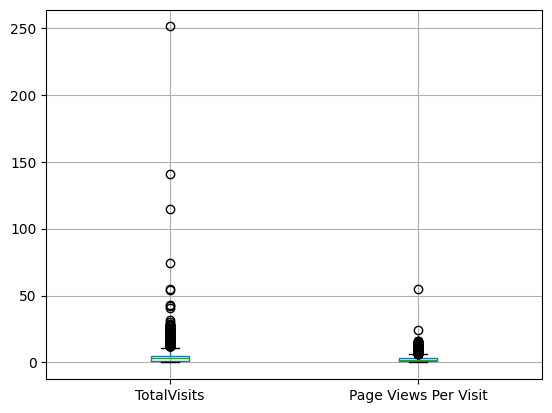

In [146]:
df[['TotalVisits', 'Page Views Per Visit']].boxplot()
plt.show()

In [147]:
df['TotalVisits'] = df['TotalVisits'].fillna(df['TotalVisits'].median())

df['Page Views Per Visit'] = df['Page Views Per Visit'].fillna(
    df['Page Views Per Visit'].median()
)

In [148]:
df.isnull().sum()

,0
Do Not Email,0
Converted,0
TotalVisits,0
Total Time Spent on Website,0
Page Views Per Visit,0
A free copy of Mastering The Interview,0
Lead Origin_Lead Add Form,0
Lead Source_Direct Traffic,0
Lead Source_Google,0
Lead Source_Olark Chat,0


In [149]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df.drop('Converted', axis=1)

# Target
y = df['Converted']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Estimated coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"Accuracy: {accuracy}")

Estimated coefficients: [[-0.56325175  0.04007201  0.00212454 -0.07625844 -0.42125632  1.01649903
  -0.69529399 -0.19764917 -0.20087372 -0.08893969  0.6822392  -0.02419444
   0.28829795 -0.31088587 -0.27658198 -0.07307948  0.24180397 -0.03116561
  -0.53072349 -0.19935158  0.78666346  0.04593135  0.012348   -0.76493324
   0.71547339  0.04585493 -0.0012962   0.05501655  0.03990904 -0.04202136
   0.021888   -0.02130585 -0.05249077  0.12306381 -0.01718016  0.03805608
  -0.03862735 -0.00377781 -0.01624794 -0.49434925 -0.02173819 -0.5269362
  -0.76246769  1.00834338 -0.77943155 -0.01591423  0.00152903  0.05970317
  -0.09533885 -0.07380797 -0.69321306 -0.11757974 -0.11584783  0.68525387]]
Intercept: [-0.24470624]
Accuracy: 0.8327922077922078


In [150]:
from sklearn.metrics import accuracy_score, confusion_matrix  # Importing accuracy_score and confusion_matrix functions from sklearn.metrics
# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

[[988 119]
 [190 551]]


TRue Negative - 988 - model predicted correctly those not converted
False positive - 119 - The model predicted Converted, but the lead did not convert.
False negative- 190 - The model predicted Not Converted, but the lead actually converted.
True Positive - 551 - model predicted correctly those  converted

In [151]:
from sklearn.metrics import precision_score, recall_score  # Importing precision_score and recall_score functions from sklearn.metrics
precision_score(y_test, y_pred)

0.8223880597014925

In [152]:
# Calculate recall score
recall_score(y_test, y_pred)

0.7435897435897436

In [153]:
# Predict class probabilities for the testing data using the trained logistic regression model
prob = model.predict_proba(X_test)
print(prob[1])

[0.96055706 0.03944294]


In [154]:
#Check VIF and improve
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
X_train_vif = X_train.astype(float)
vif['Features'] = X_train_vif.columns
vif['VIF'] = [variance_inflation_factor(X_train_vif.values, i) for i in range(X_train_vif.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
42,What is your current occupation_Unknown,244.10
44,What matters most to you in choosing a course_...,202.38
41,What is your current occupation_Unemployed,87.85
7,Lead Source_Google,35.80
6,Lead Source_Direct Traffic,32.59
16,Last Activity_Email Opened,29.66
20,Last Activity_SMS Sent,28.67
5,Lead Origin_Lead Add Form,23.55
23,Country_India,23.48
8,Lead Source_Olark Chat,21.83


In [90]:
X_train.columns.tolist()

['Do Not Email',
 'TotalVisits',
 'Total Time Spent on Website',
 'Page Views Per Visit',
 'A free copy of Mastering The Interview',
 'Lead Origin_Lead Add Form',
 'Lead Source_Direct Traffic',
 'Lead Source_Google',
 'Lead Source_Olark Chat',
 'Lead Source_Organic Search',
 'Lead Source_Reference',
 'Lead Source_Referral Sites',
 'Lead Source_Welingak Website',
 'Last Activity_Converted to Lead',
 'Last Activity_Email Bounced',
 'Last Activity_Email Link Clicked',
 'Last Activity_Email Opened',
 'Last Activity_Form Submitted on Website',
 'Last Activity_Olark Chat Conversation',
 'Last Activity_Page Visited on Website',
 'Last Activity_SMS Sent',
 'Last Activity_Unknown',
 'Last Activity_Unreachable',
 'Country_India',
 'Country_Unknown',
 'Specialization_Business Administration',
 'Specialization_E-COMMERCE',
 'Specialization_Finance Management',
 'Specialization_Healthcare Management',
 'Specialization_Hospitality Management',
 'Specialization_Human Resource Management',
 'Specializ

In [155]:
X_train = X_train.drop(
    columns=['Last Activity_SMS Sent']
)
X_test = X_test.drop(
    columns=['Last Activity_SMS Sent']
)

In [156]:
X_train = X_train.drop(
    columns=['Country_India']
)
X_test = X_test.drop(
    columns=['Country_India']
)

In [157]:
# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
X_train_vif = X_train.astype(float)
vif['Features'] = X_train_vif.columns
vif['VIF'] = [variance_inflation_factor(X_train_vif.values, i) for i in range(X_train_vif.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
40,What is your current occupation_Unknown,231.91
42,What matters most to you in choosing a course_...,201.83
39,What is your current occupation_Unemployed,69.93
7,Lead Source_Google,33.22
6,Lead Source_Direct Traffic,30.53
5,Lead Origin_Lead Add Form,23.30
8,Lead Source_Olark Chat,20.97
9,Lead Source_Organic Search,14.39
10,Lead Source_Reference,13.86
22,Country_Unknown,13.06


In [158]:
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Estimated coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"Accuracy: {accuracy}")

Estimated coefficients: [[-5.99867455e-01  3.44313996e-02  2.06649509e-03 -8.67851721e-02
  -4.52778092e-01  1.16566714e+00 -7.69101092e-01 -3.68235429e-01
  -1.12569473e-01 -1.28407370e-01  7.78856539e-01 -3.95414480e-02
   3.30661244e-01 -4.00978768e-01 -3.32243410e-01 -1.16862283e-01
  -1.65285749e-01 -5.52751085e-02 -6.25140286e-01 -3.03398413e-01
   5.25585136e-02 -3.18846769e-03  9.89593803e-01  4.54534378e-02
   4.31997033e-04  3.67274204e-02  4.26804113e-02 -4.95514496e-02
   9.00411110e-03 -2.59766351e-02 -5.31490289e-02  1.17916881e-01
  -2.10369293e-02  3.98826564e-02 -4.33881378e-02  7.88349458e-04
  -1.99058469e-02 -5.07750819e-01 -3.78508691e-02 -6.50071793e-01
  -7.67601116e-01  1.09420559e+00 -7.87909575e-01 -1.03468375e-02
   1.30625839e-02  3.75238760e-02 -5.59416073e-02 -1.05158795e-01
  -8.06963758e-01 -1.41604148e-01 -1.76917237e-01  1.26534708e+00]]
Intercept: [-0.30372147]
Accuracy: 0.821969696969697


In [159]:
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

[[984 123]
 [206 535]]


Accuracy and confusion performance has dropped ..remove only rlevant column and check